<a href="https://colab.research.google.com/github/prasa129/Math/blob/main/quad_opt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unconstrained Quadratic Optimization

12-25-2025

Code to implement unconstrained quadratic optimization, following Prof. Peter Olver's (UMN) notes.

---

## Setup

Let $x \in \mathbb{R}^n$ and consider the unconstrained quadratic objective

$$
f(x) \;=\; \tfrac12 x^\top Q x \;+\; b^\top x \;+\; c,
$$

where $Q \in \mathbb{R}^{n\times n}$ is symmetric, $b \in \mathbb{R}^n$, and $c \in \mathbb{R}$. The gradient and Hessian are

$$
\nabla f(x) \;=\; Qx + b,
\qquad
\nabla^2 f(x) \;=\; Q.
$$

Critical points satisfy FOC

$$
Qx + b = 0.
$$

Existence, uniqueness, and the nature (minimum/maximum) of an optimizer are completely determined by the definiteness of $Q$ and, in the case of $Q$ singular, by whether any component of $b$ lies in the nullspace of $Q$ (ker $Q$). Suppose an objective function $f(x)$ is given in expanded polynomial form. If $f$ is quadratic in $x$, then
$$
Q \;=\; \nabla^2 f(x),
\qquad
b \;=\; \nabla f(0),
\qquad
c \;=\; f(0),
$$
which provides a mapping from a generic quadratic to the canonical
form.

## Classification of Q

Let the spectral decomposition of $Q$ be
$$
Q \;=\; V \Lambda V^\top,
$$
where
$$
\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_n),
$$
with orthonormal eigenvectors $V$ and real eigenvalues $\{\lambda_i\}_{i=1}^n$.
Definiteness is characterized by the signs of $\lambda_i$:
$$
Q \succ 0 \iff \lambda_i > 0\ \forall i,
\qquad
Q \succeq 0 \iff \lambda_i \ge 0\ \forall i,
$$
$$
Q \prec 0 \iff \lambda_i < 0\ \forall i,
\qquad
Q \preceq 0 \iff \lambda_i \le 0\ \forall i,
$$
Thus $Q$ is PD (ND) if all eigenvalues are strictly positive (negative), and $Q$ is PSD (NSD) if all eigenvalues are non-negative (non-positive). $Q$ is indefinite if it has at least one positive and at least one negative eigenvalue. When $Q=0$, all eigenvalues are 0.

## Existence and Uniqueness of Optima

The existence and uniquness of a global minimum or maximum is determined solely by $Q$'s curvature.

### 1. Q Positive Definite

If $Q \succ 0$, then $f$ is strictly convex and the FOC has a unique solution since $Q$ is invertible:
$$
x^{*} \;=\; -Q^{-1}b.
$$
Moreover, completing the square yields
$$
f(x)
\;=\;
\tfrac12 (x-x^{*})^\top Q (x-x^{*}) + f(x^{*}),
$$
such that for all $x\neq x^{*}$,
$$
f(x)-f(x^{*})
\;=\;
\tfrac12 (x-x^{*})^\top Q (x-x^{*}) \;>\; 0.
$$
Hence $x^{*}$ is the unique global minimizer.

### 2. Q Negative Definite

If $Q \prec 0$, then $f$ is strictly concave and again $Q$ is invertible, so the unique solution is
$$
x^{*} \;=\; -Q^{-1}b.
$$
Completing the square gives the same identity, but the quadratic form is negative:
$$
f(x)-f(x^{*})
\;=\;
\tfrac12 (x-x^{*})^\top Q (x-x^{*}) \;<\; 0
\quad\text{for all } x\neq x^{*},
$$
so $x^{*}$ is the unique global maximizer.

### 3. Q Indefinite

If $Q$ has both positive and negative eigenvalues, then $f$ is unbounded above and below. Let $v_+$ be an eigenvector with eigenvalue $\lambda_+>0$ and $v_-$ an eigenvector with eigenvalue $\lambda_-<0$. Along the directions $x = t v_{\pm}$,

$$
f(tv_\pm)
\;=\;
\tfrac12 \lambda_\pm t^2 + t\, b^\top v_\pm + c.
$$

As $|t|\to\infty$, the quadratic term dominates: $f(tv_+)\to +\infty$ and $f(tv_-)\to -\infty$. Thus no global minimum or maximum exists.

### 4. Q = 0

If $Q=0_{n \times n}$ (the zero matrix), then

$$
f(x) = b^\top x + c.
$$

If $b=0$, then $f(x)= c$ is constant and every $x$ is both a minimizer and a maximizer. If $b\neq 0$, then $b^\top x$ is unbounded above and below by moving along $\pm b$, so no global optimum exists.

### 5. Q Positive Semidefinite

Assume $Q\succeq 0$. If $Q$ is singular, the kernel

$$
\text{ker } Q \;=\; \{z\in\mathbb{R}^n : Qz=0\}
$$

is non-trivial. For any $z\in \text{ker Q}$ and scalar $t$,

$$
f(x+tz)
=
\tfrac12 (x+tz)^\top Q(x+tz) + b^\top(x+tz) + c
=
f(x) + t\, b^\top z,
$$

since $Qz=0$ eliminates both $t^2$ and $t$'s contributions from the quadratic term. It follows that

1. If there exists $z\in\text{ker Q}$ with $b^\top z \neq 0$, then choosing $t\to -\infty$ such that $t\,b^\top z\to -\infty$ implies $f(x+tz)\to -\infty$. Hence $f$ is unbounded below and no global minimum exists.

2. If $b^\top z = 0$ for all $z\in\text{ker Q}$, i.e. $b \perp \text{ker Q}$, then $f(x)$ is flat along null directions and a global minimum exists.

Because $Q$ is symmetric, the condition $b$ orthogonal to the kernel is equivalent to $b$ lies in the image of $Q$, and thus the FOC $Qx=-b$ can be solved. When a minimum exists, it is generally non-unique. If $x^{*}$ solves $Qx=-b$, then so does $x^{*}+z$ for any $z\in\text{ker Q}$, e.g. the minimum-norm solution obtained using least squares.

### 6. Q Negative Semidefinite

Assume $Q\preceq 0$ and define $\text{ker Q}$ as above. The same calculation yields $f(x+tz)=f(x)+t\,b^\top z$ for $z\in\text{ker Q}$. Thus:

1. If there exists $z\in\text{ker Q}$ with $b^\top z\neq 0$, then $f$ is unbounded above (let $t\to +\infty$), so no global maximum exists.

2. If $b\perp \text{ker Q}$, then a global maximum exists but is typically non-unique (flat directions), e.g. the minimum-norm maximizer satisfying $Qx=-b$.


## Solving for $x^{*}$

When $Q$ is invertible (PD or ND), the optimizer is uniquely characterized by

$$
Qx^{*} = -b,
\qquad
x^{*} = -Q^{-1}b.
$$

Solving the linear system $Qx=-b$ for $x^{*}$ avoids numerical issues with computing $Q^{-1}$ explicitly.

## Condition Number and Sensitivity


In the PD/ND cases, the spectral condition number is

$$
\kappa(Q) \;=\; \frac{\lambda_{\max}(Q)}{\lambda_{\min}(Q)}.
$$

A high $\kappa(Q)$ indicates ill-conditioning and high sensitivity of the optimizer to perturbations in $b$:
$$
x^{*} = -Q^{-1}b
\quad\Rightarrow\quad
\delta x^{*} = -Q^{-1}\delta b,
\qquad
\|\delta x^{*}\| \le \|Q^{-1}\|\,\|\delta b\|
= \frac{1}{\lambda_{\min}(Q)} \|\delta b\|.
$$

Thus I report $\kappa(Q)$ and flag potential numerical or statistical instability.

I define a quadratic optimization class and test it using example functions for each case.




In [1]:
# standard imports
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


class QuadraticOpt:
    """
    Unconstrained quadratic optimization for the form:
    f(x) = 0.5 * x' Q x + b' x + c.
    The class does the following:
    - Parse a generic quadratic expression from a string using sympy
    - Extract Q, b, c using Hessian and gradient
    - Classify PD, PSD, ND, NSD, indefinite, 0 matrix using eigenvalues
    - Determine existence and uniqueness of a global min/max
    - Solve for x* using linear solve or least squares
    - Report eigenvalues and condition number (warning for ill-conditioned)
    - Contour plots for n=1 or n=2
    """

    def __init__(self, expr_str, variables, simplify=True, eig_tol=1e-10, cond_warn=1e12):
        """
        Parameters
        ----------
        expr_str : str
            Objective expression as a string, quadratic in the given variables.
        variables : list[str]
            Variable names in order, e.g. ["x0","x1","x2"].
        simplify : bool
            If True, simplify sympy expression prior to extraction.
        eig_tol : float
            Eigenvalue tolerance used for sign classification and nullspace detection.
        cond_warn : float
            Condition number threshold to flag ill-conditioning (PD/ND primarily).
        """
        # capture inputs
        self.expr_str = expr_str
        self.variables = list(variables)
        self.simplify = bool(simplify)
        self.eig_tol = float(eig_tol)
        self.cond_warn = float(cond_warn)

        # validate inputs
        if len(self.variables) == 0:
            msg = "variables must be a non-empty list of variable names."
            raise ValueError(msg)

        # create sympy symbols in the given order (sets coordinate system)
        self.syms = sp.symbols(self.variables, real=True)

        # build local mapping
        sym_map = {str(s): s for s in self.syms}

        # parse input string
        self.expr = sp.sympify(self.expr_str, locals=sym_map)

        # simplify expression
        if self.simplify:
            self.expr = sp.simplify(self.expr)

        # capture polynomimal degree
        poly = sp.Poly(self.expr, *self.syms, domain="RR")

        # if degree > 2, raise error
        if poly.total_degree() > 2:

            # polynomial must be quadratic
            msg = f"Polynomial degree {poly.total_degree()} > 2, must be quadratic."
            raise ValueError(msg)

        # symbolic to numeric form conversion (Q, b, c)
        self.build_quadratic_form()

        # capture spectral decomposition QVQ'
        self.eigvals, self.eigvecs = np.linalg.eigh(self.Q)

    def build_quadratic_form(self):
        """
        Extract Q, b, c using Hessian/gradient identities. For a quadratic f(x):
        Hessian is constant and equals Q, grad f(x) = Qx + b, and constant is
        f(0) = c. Compute H and g, evaluate at x=0, and store.
        """
        # compute n x n Hessian
        H = sp.hessian(self.expr, self.syms)

        # compute n x 1 gradient
        g = sp.Matrix([sp.diff(self.expr, s) for s in self.syms])

        # create substitution dictionary to eval at x=0
        zero_subs = {s: 0 for s in self.syms}

        # Q, b, c
        Q_sym = sp.Matrix(H)
        b_sym = sp.Matrix(g.subs(zero_subs))
        c_sym = sp.N(self.expr.subs(zero_subs))

        # convert to numpy arrays
        Q = np.array(Q_sym.evalf(), dtype=float)
        b = np.array(b_sym.evalf(), dtype=float).reshape(-1)
        c = float(c_sym)

        # make sure Q is symmetric
        Q = 0.5 * (Q + Q.T)

        # store Q, b, c
        self.Q, self.b, self.c = Q, b, c

    def f(self, x):
        """
        Evaluate f(x) = 0.5 x'Qx + b'x + c, where x is a vector.
        """
        # reshape x to 1D array
        x = np.asarray(x, dtype=float).reshape(-1)

        # evaluate f(x) and return
        return float(0.5 * x @ self.Q @ x + self.b @ x + self.c)

    def grad(self, x):
        """
        Evaluate gradient Qx + b.
        """
        # reshape x to 1D array
        x = np.asarray(x, dtype=float).reshape(-1)

        # compute gradient and return
        return self.Q @ x + self.b

    def classify(self):
        """
        Classify curvature based on Q's eigenvalues. Note, condition number
        for symmetric matrix is ratio of largest to smallest eigenvalue.

        Returns
        -------
        out : dict
            kind : str
                "PD", "PSD", "ND", "NSD", "INDEFINITE", or "ZERO"
            eigenvalues : np.ndarray
                Eigenvalues of Q sorted ascending by eigh convention.
            tol : float
                Tolerance used for classification.
            condition_number : float or None
                For PD/ND: lambda_max / lambda_min (in magnitude).
                For singular PSD/NSD: pseudo condition number when meaningful.
            ill_conditioned : bool
                True if condition_number exceeds cond_warn.
            notes : str
                Description of classification.
        """
        # copy stored evalues
        lam = self.eigvals.copy()

        # tolerance for zero
        tol = self.eig_tol

        # create boolean masks for sign
        pos = lam > tol
        neg = lam < -tol
        zero = np.abs(lam) <= tol

        # classify
        """
        If Q is PD: unique global minimum exists, x* solves Q x = -b.
        If Q is ND: unique global maximum exists, x* solves Q x = -b.
        If Q is PSD (singular): global minimum exists iff b orthogonal to ker Q,
        return minimum norm solution.
        If Q is NSD (singular): global maximum exists iff b orthogonal to ker Q,
        return minimum norm solution.
        If Q is indefinite, function unbounded above and below.
        If Q is 0, objective is linear/constant and unbounded unless b=0.
        """
        # all 0 eigenvalues
        if np.all(zero):

            # f(x) is linear or constant
            kind = "ZERO"
            cond = None
            notes = "Q is (numerically) zero: f(x) is linear/constant."

        # all positive eigenvalues
        elif np.all(pos):

            # Q is PD
            kind = "PD"
            cond = float(lam.max() / lam.min())
            notes = "Q is PD: f(x) has unique global minimum."

        # all negative eigenvalues
        elif np.all(neg):

            # Q is ND
            kind = "ND"
            cond = float(np.abs(lam).max() / np.abs(lam).min())
            notes = "Q is ND: f(x) has unique global maximum."

        # all non-negative eigenvalues
        elif np.all(lam >= -tol):

            # Q is PSD
            kind = "PSD"

            # count strictly positive eigenvalues
            lam_pos = lam[lam > tol]

            # compute condition number if at least 2 strictly positive eigenvalues
            cond = float(lam_pos.max() / lam_pos.min()) if lam_pos.size >= 2 else None

            # f(x) convex
            notes = "Q is PSD: f(x) convex but may have non-unique optimum."

        # all non-positive eigenvalues
        elif np.all(lam <= tol):

            # Q is NSD
            kind = "NSD"

            # count strictly negative eigenvalues
            lam_neg = np.abs(lam[lam < -tol])


            # compute condition number if at least 2 strictly negative eigenvalues
            cond = float(lam_neg.max() / lam_neg.min()) if lam_neg.size >= 2 else None

            # f(x) concave # concave but possibly singular
            notes = "Q is NSD: f(x) concave but may have non-unique optimum."

        # mixed eigenvalues
        else:

            # Q is indefinite (saddle point)
            kind = "INDEFINITE"
            cond = None
            notes = "Q is indefinite: f(x) has no global min or max."

        # set ill cond. flag only when cond. number exceeds tol
        if cond is not None and cond >= self.cond_warn:
            ill = True
        else:
            ill = False

        # return information dictionary
        return {"kind": kind, "eigenvalues": lam, "tol": tol,
                "condition_number": cond, "ill_conditioned": ill,
                "notes": notes}

    def solve(self):
        """
        Solve for a global optimum if it exists.

        Returns
        -------
        out : dict
            status : str
                "GLOBAL_MIN", "GLOBAL_MAX", "MULTIPLE_OPTIMA", "UNBOUNDED", "NO_OPTIMUM"
            x_star : np.ndarray or None
                Optimizer (minimum-norm choice if multiple).
            f_star : float or None
                Objective value at x_star.
            details : str
                Plain-language explanation of outcome.
        """
        # classify curvature
        cls = self.classify()

        # capture definiteness
        kind = cls["kind"]

        # local Q, b, n, tolerance
        Q = self.Q
        b = self.b
        n = Q.shape[0]
        tol = self.eig_tol

        # Q indefinite
        if kind == "INDEFINITE":

            # f(x) unbounded
            return {"status": "UNBOUNDED","x_star": None,"f_star": None,
                    "details": "Q indefinite: f(x) unbounded below and above."}

        # Q numerically zero
        if kind == "ZERO":

            # b numerically 0
            if np.linalg.norm(b) <= tol:

                # f(x) constant, all x optimal
                x0 = np.zeros(n, dtype=float)
                return {"status": "MULTIPLE_OPTIMA","x_star": x0,"f_star": self.f(x0),
                        "details": "f(x) constant: every x is optimal. Returned x=0."}

            # b nonzero, f(x) linear and unbounded
            return {"status": "UNBOUNDED","x_star": None,"f_star": None,
                    "details": "f(x) linear with nonzero b: unbounded."}

        # Q PD or ND
        if kind in ["PD", "ND"]:

            # try solving Qx = -b
            try:
                x_star = np.linalg.solve(Q, -b)

            # catch numeric issues
            except np.linalg.LinAlgError:

                # use least squares as fallback
                x_star, *_ = np.linalg.lstsq(Q, -b, rcond=None)

            # compute f(x*)
            f_star = self.f(x_star)

            # set status based on Q
            if kind=="PD":
                status = "GLOBAL_MIN"
            else:
                status = "GLOBAL_MAX"

            # unique optimum x = -(Q^-1)b
            return {"status": status,"x_star": x_star,"f_star": f_star,
                    "details": "f(x) uq. optimum using Qx = -b."}


        # Q PSD or NSD
        if kind in ["PSD", "NSD"]:

            # capture nullspace directions for zero eigenvalues
            null_mask = np.abs(self.eigvals) <= tol
            Vnull = self.eigvecs[:, null_mask]

            # if no nullspace detected (within tol.), treat Q as full-rank
            if Vnull.size == 0:

                try:
                    # solve Qx = -b
                    x_star = np.linalg.solve(Q, -b)

                # catch errors
                except np.linalg.LinAlgError:

                    # use LS as backup
                    x_star, *_ = np.linalg.lstsq(Q, -b, rcond=None)

                # commpute f(x*)
                f_star = self.f(x_star)

                # set status
                if kind == "PSD":
                    status = "GLOBAL_MIN"
                else:
                    status = "GLOBAL_MAX"

                # return dict
                return {"status": status,"x_star": x_star,"f_star": f_star,
                        "details": "Q near-singular but nullspace empty, Qx=-b solved normally."}


            """
            Final cases:
            - Q PSD, min. exists iff b is orthogonal to ker Q
            - Q NSD, max. exists iff b is orthogonal to ker Q
            If b has a component in the nullspace of Q, then along z in ker Q,
            quadratic term is zero but linear term shifts by t*(b'z).
            """
            # project b onto nullspace of Q
            proj = Vnull.T @ b

            # set baseline for norm of projection
            baseline = 100 * tol * max(1.0, np.linalg.norm(b))

            # if norm of projection exceeds baseline, b has component in nullspace
            if np.linalg.norm(proj) > baseline:

                # if Q PSD
                if kind == "PSD":

                    # f(x) unbounded
                    return {"status": "UNBOUNDED", "x_star": None,"f_star": None,
                            "details": "Q PSD but b has component in Null(Q), no min."}

                # Q NSD
                else:

                    # f(x) unbounded
                    return {"status": "UNBOUNDED","x_star": None,"f_star": None,
                            "details": "Q NSD but b has component in Null(Q), no max."}


            # otw, projection norm is zero
            else:

              # return min. norm sol. to Qx=-b using LS
              x_star, *_ = np.linalg.lstsq(Q, -b, rcond=None)

              # compute f(x*)
              f_star = self.f(x_star)


              # min. if Q PSD
              if kind == "PSD":
                opt = "GLOBAL_MIN"

              # max. if Q NSD
              else:
                opt = "GLOBAL_MAX"

              # optimum exists but isn't unique
              return {"status": "MULTIPLE_OPTIMA","x_star": x_star,"f_star": f_star,
                      "details": f"Q {kind}, {opt} exists but is not unique. Returned minimum-norm x*."}


        # fallback case
        return {"status": "NO_OPTIMUM","x_star": None,"f_star": None,
                "details": "Error."}

    def report(self):
        """
        Produce a compact summary.

        Returns
        -------
        out : dict
            Includes classification, solution, and any warning message.
        """
        # compute classification and solve
        cls = self.classify()
        sol = self.solve()

        # merge dictionaries
        out = {}
        out.update(cls)
        out.update(sol)

        # include warning if Q ill conditioned
        if cls["ill_conditioned"] and cls["condition_number"] is not None:
            out["warning"] = (f"WARNING: Condition number {cls['condition_number']:.3e} exceeds threshold {self.cond_warn:.3e}.")
        else:
            out["warning"] = None

        return out

    def plot(self,x_star=None,bounds=(-5.0, 5.0),grid=250,levels=30):
        """
        Plot objective for n=1 or n=2.
        - n=1: line plot over [lo, hi].
        - n=2: contour plot of level sets over a grid, with x_star marked.
        """
        # capture n from Q
        n = self.Q.shape[0]

        # unpack plotting domain
        lo, hi = float(bounds[0]), float(bounds[1])

        # n=1: plot f(x) vs x
        if n == 1:

            # sample x, y
            xs = np.linspace(lo, hi, grid)
            ys = np.array([self.f([t]) for t in xs], dtype=float)

            # plot
            plt.figure()
            plt.plot(xs, ys)
            plt.xlabel(str(self.syms[0]))
            plt.ylabel("f(x)")
            plt.title("Quadratic objective (n=1)")

            # plot optimizer
            if x_star is not None:

                # flatten x*
                x_star = np.asarray(x_star, dtype=float).reshape(-1)

                # scatter x*, f(x*)
                plt.scatter([x_star[0]], [self.f(x_star)], marker="o")

            # show plot
            plt.show()
            return

        # n=2: contour plot of f(x1, x2)
        if n == 2:

            # build grid
            x1 = np.linspace(lo, hi, grid)
            x2 = np.linspace(lo, hi, grid)
            X1, X2 = np.meshgrid(x1, x2)
            Z = np.empty_like(X1, dtype=float)


            # loop through grid indices
            for i in range(grid):
                for j in range(grid):

                    # fill f(x) values on grid
                    Z[i, j] = self.f([X1[i, j], X2[i, j]])


            # plot level sets
            plt.figure()
            cs = plt.contour(X1, X2, Z, levels=levels)
            plt.clabel(cs, inline=True, fontsize=8)

            # label axes, set title
            plt.xlabel(str(self.syms[0]))
            plt.ylabel(str(self.syms[1]))
            plt.title("Quadratic level sets (n=2)")

            # plot optimizer
            if x_star is not None:

                # flatten x*
                x_star = np.asarray(x_star, dtype=float).reshape(-1)

                # scatter x*, f(x*)
                plt.scatter([x_star[0]], [x_star[1]], marker="o")

            # show plot
            plt.show()
            return

        # raise error for n > 2
        msg = f"Plotting supported only for n=1 or n=2, not n={n}."
        raise ValueError(msg)



## Ex.1: PD, well-conditioned

The objective is
$$
f(x_0,x_1)=3x_0^2 + 2x_0x_1 + 2x_1^2 - 4x_0 + x_1 + 5
$$
with gradient
$$
\nabla f(x)
=
\begin{pmatrix}
6x_0 + 2x_1 - 4\\
2x_0 + 4x_1 + 1
\end{pmatrix},
$$
so the Hessian and linear term are
$$
Q =
\begin{pmatrix}
6 & 2\\
2 & 4
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
-4\\
1
\end{pmatrix},
\qquad
c = 5.
$$

The eigenvalues of $Q$ are
$$
(6-\lambda)(4-\lambda)-4=0 \implies \lambda=
5\pm\sqrt{5},
$$
numerically
$$
\lambda_- \approx 2.7639,
\qquad
\lambda_+ \approx 7.2361,
$$
so $Q \succ 0$. The FOC $Qx + b = 0$ gives
$$
\begin{pmatrix}
6 & 2\\
2 & 4
\end{pmatrix}
\begin{pmatrix}
x_0\\
x_1
\end{pmatrix}
=
\begin{pmatrix}
4\\
-1
\end{pmatrix}.
$$
Solving,
$$
x_0 = \frac{9}{10},
\qquad
x_1 = -\frac{7}{10},
$$
so
$$
x^{*} =
\begin{pmatrix}
0.9\\
-0.7
\end{pmatrix}.
$$

The optimal value is
$$
\begin{aligned}
f(x^{*})
&=
3\left(\frac{9}{10}\right)^2
+2\left(\frac{9}{10}\right)\left(-\frac{7}{10}\right)
+2\left(-\frac{7}{10}\right)^2
-4\left(\frac{9}{10}\right)
-\frac{7}{10}
+5\\
&= 2.85.
\end{aligned}
$$

The condition number is
$$
\kappa_2(Q)
=
\frac{\lambda_{\max}}{\lambda_{\min}}
=
\frac{5+\sqrt{5}}{5-\sqrt{5}}
=
\frac{3+\sqrt{5}}{2}
\approx 2.6180.
$$

Case 1: PD (unique global minimum)

kind: PD
eigenvalues: [2.76393202 7.23606798]
tol: 1e-10
condition_number: 2.618033988749895
ill_conditioned: False
notes: Q is PD: f(x) has unique global minimum.
status: GLOBAL_MIN
x_star: [ 0.9 -0.7]
f_star: 2.8499999999999996
details: f(x) uq. optimum using Qx = -b.


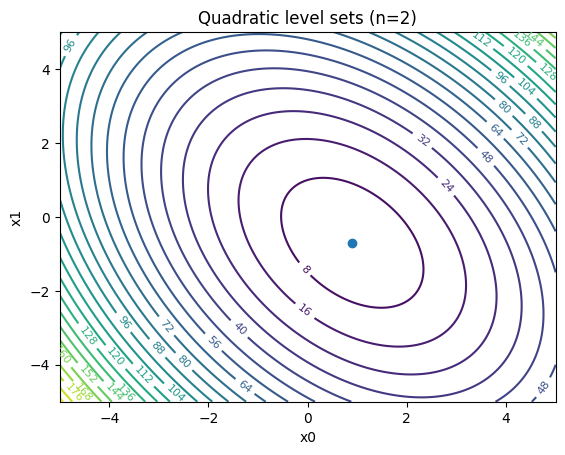

In [2]:
# set f(x)
expr = "3*x0**2 + 2*x0*x1 + 2*x1**2 - 4*x0 + 1*x1 + 5"

# optimize
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])

# generate report
rep = q.report()

# check output
print("Case 1: PD (unique global minimum)\n")
for k,v in rep.items():
    print(f"{k}: {v}")

# plot
q.plot(x_star=rep["x_star"], bounds=(-5, 5))

## Ex.2: ND

\begin{align*}
f(x_0,x_1) &= -x_0^2 - 2x_1^2 + 3x_0 - 2x_1 \\
\nabla f(x) &=
\begin{pmatrix}
-2x_0 + 3\\
-4x_1 - 2
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
-2 & 0\\
0 & -4
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
3\\
-2
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = -2,\qquad \lambda_2 = -4 \implies Q \prec 0
$$

$$
Qx + b = 0 \implies
x^{*} =
\begin{pmatrix}
1.5\\
-0.5
\end{pmatrix}.
$$

$$
\begin{aligned}
f(x^{*})
&=
-\left(\frac{3}{2}\right)^2 - 2\left(-\frac{1}{2}\right)^2
+ 3\left(\frac{3}{2}\right) - 2\left(-\frac{1}{2}\right)\\
&=
-\frac{9}{4} - 2\cdot\frac{1}{4} + \frac{9}{2} + 1=2.75.
\end{aligned}
$$

$$
\kappa_2(Q)
=
\frac{|\lambda_{\max}|}{|\lambda_{\min}|}
=
\frac{4}{2}
=
2.
$$



Case 2: ND (unique global maximum)

kind: ND
eigenvalues: [-4. -2.]
tol: 1e-10
condition_number: 2.0
ill_conditioned: False
notes: Q is ND: f(x) has unique global maximum.
status: GLOBAL_MAX
x_star: [ 1.5 -0.5]
f_star: 2.75
details: f(x) uq. optimum using Qx = -b.


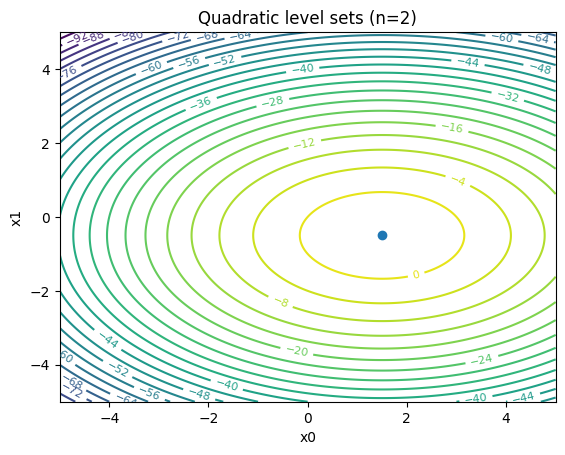

In [3]:
# set f(x)
expr = "-(x0**2 + 2*x1**2) + 3*x0 - 2*x1"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 2: ND (unique global maximum)\n")
for k, v in rep.items():
    print(f"{k}: {v}")

# plot
q.plot(x_star=rep["x_star"], bounds=(-5, 5))

## Ex.3: Indefinite (saddle)

\begin{align*}
f(x_0,x_1) &= x_0^2 - x_1^2 + 2x_0\\
\nabla f(x) &=
\begin{pmatrix}
2x_0 + 2\\
-2x_1
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
2 & 0\\
0 & -2
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
2\\
0
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = 2,\qquad \lambda_2 = -2 \implies Q \ \text{indefinite}
$$

$$
Qx + b = 0 \implies
x^{\text{stat}} =
\begin{pmatrix}
-1\\
0
\end{pmatrix}.
$$

$$
f\!\left(x^{\text{stat}}\right)
=
(-1)^2 - 0^2 + 2(-1)
=
-1.
$$

$$
f(t,0) = t^2 + 2t \to +\infty \ \text{as}\ t\to\infty,
\qquad
f(0,t) = -t^2 \to -\infty \ \text{as}\ t\to\infty.
$$

Thus there is no global minimum or maximum.


In [4]:
# set f(x)
expr = "x0**2 - x1**2 + 2*x0"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 3: INDEFINITE (unbounded)\n")
for k, v in rep.items():
    print(f"{k}: {v}")


Case 3: INDEFINITE (unbounded)

kind: INDEFINITE
eigenvalues: [-2.  2.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is indefinite: f(x) has no global min or max.
status: UNBOUNDED
x_star: None
f_star: None
details: Q indefinite: f(x) unbounded below and above.


## Ex.4: Constant

$f(x)=7$.

In [5]:
# set f(x)
expr = "7"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 4: ZERO constant (multiple optima)\n")
for k, v in rep.items():
    print(f"{k}: {v}")


Case 4: ZERO constant (multiple optima)

kind: ZERO
eigenvalues: [0. 0.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is (numerically) zero: f(x) is linear/constant.
status: MULTIPLE_OPTIMA
x_star: [0. 0.]
f_star: 7.0
details: f(x) constant: every x is optimal. Returned x=0.


## Ex.5: Zero Hessian (linear)

\begin{align*}
f(x_0,x_1) &= 3x_0 - 2x_1 + 1\\
\nabla f(x) &=
\begin{pmatrix}
3\\
-2
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
0 & 0\\
0 & 0
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
3\\
-2
\end{pmatrix},
\qquad
c = 1
$$

$$
\lambda_1 = 0,\qquad \lambda_2 = 0 \implies Q = 0
$$

$b \neq 0$ implies f is linear and unbounded above and below.

$$
f(t,0) = 3t + 1 \to +\infty \ \text{as}\ t\to\infty,
\qquad
f(-t,0) = -3t + 1 \to -\infty \ \text{as}\ t\to\infty.
$$


In [6]:
# set f(x)
expr = "3*x0 - 2*x1 + 1"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 5: ZERO linear (unbounded)\n")
for k, v in rep.items():
    print(f"{k}: {v}")


Case 5: ZERO linear (unbounded)

kind: ZERO
eigenvalues: [0. 0.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is (numerically) zero: f(x) is linear/constant.
status: UNBOUNDED
x_star: None
f_star: None
details: f(x) linear with nonzero b: unbounded.


## Ex.6: PSD (min. exists, not unique)

\begin{align*}
f(x_0,x_1) &= x_0^2 + 2x_0\\
\nabla f(x) &=
\begin{pmatrix}
2x_0 + 2\\
0
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
2 & 0\\
0 & 0
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
2\\
0
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = 2,\qquad \lambda_2 = 0 \implies Q \succeq 0 \ \text{(singular)}
$$

$$
Qx + b = 0 \implies
\begin{cases}
2x_0 + 2 = 0\\
0 = 0
\end{cases}
\ \Longrightarrow\
x_0^{*} = -1,\ \ x_1 \ \text{free}.
$$

$$
\text{ker Q} = \mathrm{span}\!\left\{
\begin{pmatrix}
0\\
1
\end{pmatrix}
\right\},
\qquad
b^\top
\begin{pmatrix}
0\\
1
\end{pmatrix}
=0
\ \Longrightarrow\ \text{minimum exists.}
$$

Minimizers are
$$
\left\{
\begin{pmatrix}
-1\\
t
\end{pmatrix}
:\ t\in\mathbb{R}
\right\}$$
with minimum-norm $x^{*} =
\begin{pmatrix}
-1\\
0
\end{pmatrix}.$

$$
f(x^{*}) = f(-1,t) = (-1)^2 + 2(-1) = -1.
$$



Case 6: PSD (min exists, not unique)

kind: PSD
eigenvalues: [0. 2.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is PSD: f(x) convex but may have non-unique optimum.
status: MULTIPLE_OPTIMA
x_star: [-1.  0.]
f_star: -1.0
details: Q PSD, GLOBAL_MIN exists but is not unique. Returned minimum-norm x*.


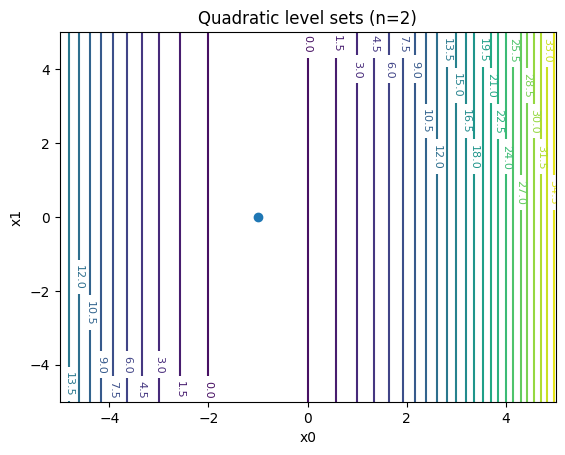

In [7]:
# set f(x)
expr = "x0**2 + 2*x0"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 6: PSD (min exists, not unique)\n")
for k, v in rep.items():
    print(f"{k}: {v}")

# plot
q.plot(x_star=rep["x_star"], bounds=(-5, 5))

## Ex.7: PSD (no minimum; unbounded below)

\begin{align*}
f(x_0,x_1) &= x_0^2 + x_1\\
\nabla f(x) &=
\begin{pmatrix}
2x_0\\
1
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
2 & 0\\
0 & 0
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
0\\
1
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = 2,\qquad \lambda_2 = 0 \implies Q \succeq 0 \ \text{(singular)}
$$

$$
\text{ker Q} = \mathrm{span}\!\left\{
\begin{pmatrix}
0\\
1
\end{pmatrix}
\right\},
\qquad
b^\top
\begin{pmatrix}
0\\
1
\end{pmatrix}
=1 \neq 0.
$$

$$
f(x + t z) = f(x) + t\, b^\top z
\ \ \text{for } z\in\text{ker Q}
$$

Take

$$
z=
\begin{pmatrix}
0\\
1
\end{pmatrix}:
\quad
f(x_0, x_1+t)=f(x_0,x_1)+t.
$$

Let $t\to -\infty \implies f(x_0,x_1+t)\to -\infty$, thus there is no global minimum.


In [8]:
# set f(x)
expr = "x0**2 + x1"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output (no plot)
print("\nCase 7: PSD (unbounded below)\n")
for k, v in rep.items():
    print(f"{k}: {v}")


Case 7: PSD (unbounded below)

kind: PSD
eigenvalues: [0. 2.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is PSD: f(x) convex but may have non-unique optimum.
status: UNBOUNDED
x_star: None
f_star: None
details: Q PSD but b has component in Null(Q), no min.


## Ex.8: NSD (no maximum)

\begin{align*}
f(x_0,x_1) &= -x_0^2 + x_1\\
\nabla f(x) &=
\begin{pmatrix}
-2x_0\\
1
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
-2 & 0\\
0 & 0
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
0\\
1
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = -2,\qquad \lambda_2 = 0 \implies Q \preceq 0 \ \text{(singular)}
$$

$$
\text{ker Q} = \mathrm{span}\!\left\{
\begin{pmatrix}
0\\
1
\end{pmatrix}
\right\},
\qquad
b^\top
\begin{pmatrix}
0\\
1
\end{pmatrix}
=1 \neq 0.
$$

$$
f(x + t z) = f(x) + t\, b^\top z
\ \ \text{for } z\in\text{ker Q}$$

Take $z=\begin{pmatrix}
0\\
1
\end{pmatrix}, f(x_0, x_1+t)=f(x_0,x_1)+t$. Let $t\to +\infty \implies f(x_0,x_1+t)\to +\infty$, thus no global maximum.


In [9]:
# set f(x)
expr = "-x0**2 + x1"

# optimize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"])
rep = q.report()

# check output
print("\nCase 8: NSD (unbounded above)\n")
for k, v in rep.items():
    print(f"{k}: {v}")


Case 8: NSD (unbounded above)

kind: NSD
eigenvalues: [-2.  0.]
tol: 1e-10
condition_number: None
ill_conditioned: False
notes: Q is NSD: f(x) concave but may have non-unique optimum.
status: UNBOUNDED
x_star: None
f_star: None
details: Q NSD but b has component in Null(Q), no max.


## Ex.9: Ill-conditioned PD

\begin{align*}
f(x_0,x_1)
&=
\tfrac12\bigl(10^{-12}x_0^2 + x_1^2\bigr) + x_0 + x_1\\
\nabla f(x)
&=
\begin{pmatrix}
10^{-12}x_0 + 1\\
x_1 + 1
\end{pmatrix}
\end{align*}

$$
Q =
\begin{pmatrix}
10^{-12} & 0\\
0 & 1
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
1\\
1
\end{pmatrix},
\qquad
c = 0
$$

$$
\lambda_1 = 10^{-12},\qquad \lambda_2 = 1
\ \implies\ Q \succ 0
$$

$$
Qx + b = 0
\ \Longrightarrow\
\begin{pmatrix}
10^{-12} & 0\\
0 & 1
\end{pmatrix}
\begin{pmatrix}
x_0\\
x_1
\end{pmatrix}
+
\begin{pmatrix}
1\\
1
\end{pmatrix}
=0
\ \Longrightarrow\
x^{*}=
\begin{pmatrix}
-10^{12}\\
-1
\end{pmatrix}.
$$

$$
\begin{aligned}
f(x^{*})
&=
\tfrac12\left(10^{-12}\cdot (10^{12})^2 + (-1)^2\right) - 10^{12} - 1\\
&=
\tfrac12\left(10^{12} + 1\right) - 10^{12} - 1
=
-\tfrac12\left(10^{12}+1\right).
\end{aligned}
$$

$$
\kappa_2(Q)
=
\frac{\lambda_{\max}}{\lambda_{\min}}
=
\frac{1}{10^{-12}}
=
10^{12}.
$$


Case 9: Ill-conditioned PD

kind: PD
eigenvalues: [1.e-12 1.e+00]
tol: 1e-16
condition_number: 1000000000000.0
ill_conditioned: True
notes: Q is PD: f(x) has unique global minimum.
status: GLOBAL_MIN
x_star: [-1.e+12 -1.e+00]
f_star: -500000000000.5
details: f(x) uq. optimum using Qx = -b.


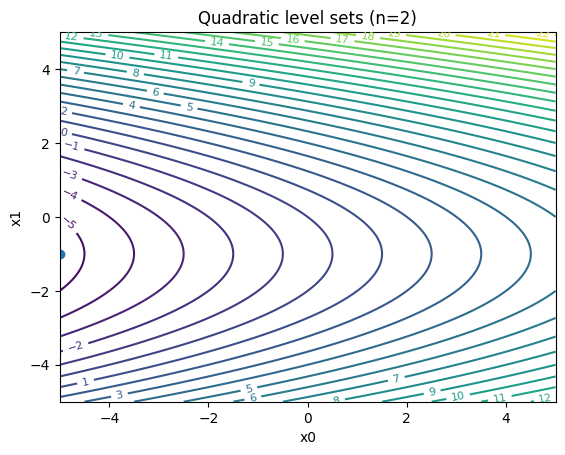

In [10]:
# set f(x)
expr = "0.5*(1e-12*x0**2 + 1*x1**2) + 1*x0 + 1*x1"

# optmize, report
q = QuadraticOpt(expr_str=expr, variables=["x0", "x1"], eig_tol=1e-16, cond_warn=1e10)
rep = q.report()

# check output
print("\nCase 9: Ill-conditioned PD\n")
for k, v in rep.items():
    print(f"{k}: {v}")

# plot shape only, mark clipped point
q.plot(x_star=np.array([-5.0, rep["x_star"][1]]), bounds=(-5, 5))

## Ex.10: Random PSD (PD), $n=6$

As a final validation step, I generate a random $f(x)$ with PD Q, and compare my class $x^{*}$ to that given by numpy.

$$
A \in \mathbb{R}^{6\times 6},\qquad
Q = A^\top A + 0.5\,I_6 \ \Rightarrow\ Q \succ 0.
$$

$$
f(x) = \tfrac12 x^\top Q x + b^\top x + c,
\qquad
b \in \mathbb{R}^6,\ \ c = 1.23.
$$

$$
\nabla f(x) = Qx + b,
\qquad
\nabla^2 f(x) = Q.
$$

$$
Qx + b = 0
\ \Longrightarrow\
x^{*} = -Q^{-1}b
\quad(\text{computed using } Qx=-b).
$$

In [11]:
# create random A (6 x 6)
rng = np.random.default_rng(0)
n = 6
A = rng.standard_normal((n, n))

# construct Q = A'A + 0.5*I_n
Q = A.T @ A + 0.5 * np.eye(n)

# construct b, arbitrary c
b = rng.standard_normal(n)
c = 1.23

# construct x0...x6 symbols
x = sp.symbols([f"x{i}" for i in range(n)], real=True)

# create sympy expression
expr_sym = 0
for i in range(n):
    for j in range(n):
        expr_sym += sp.Rational(1, 2) * float(Q[i, j]) * x[i] * x[j]
for i in range(n):
    expr_sym += float(b[i]) * x[i]
expr_sym += float(c)
expr_str = str(sp.simplify(expr_sym))

# optimize, report
q = QuadraticOpt(expr_str=expr_str, variables=[f"x{i}" for i in range(n)])
rep = q.report()

# check output
print("\nCase 10: Random PSD stress test\n")
for k, v in rep.items():
    print(f"{k}: {v}")

# compare to np solve
x_solve = np.linalg.solve(q.Q, -q.b)
print("\nComparison to np.linalg.solve(Q, -b)")
print(f"x_star: {x_solve}")


Case 10: Random PSD stress test

kind: PD
eigenvalues: [ 0.60083676  0.83160654  1.21359085  3.67014559  7.54758186 10.77568242]
tol: 1e-10
condition_number: 17.934459385138936
ill_conditioned: False
notes: Q is PD: f(x) has unique global minimum.
status: GLOBAL_MIN
x_star: [ 0.17862779  0.37800808 -0.33530848 -0.06557037  0.84229639 -1.34646362]
f_star: -0.5827675236766519
details: f(x) uq. optimum using Qx = -b.

Comparison to np.linalg.solve(Q, -b)
x_star: [ 0.17862779  0.37800808 -0.33530848 -0.06557037  0.84229639 -1.34646362]
